# FDA 이상사례 데이터 - 코드 N, E군(국소마취제/Lidocaine) 인사이트 분석

전체 FDA 이상사례 보고 데이터 중 ATC 1단계 코드 N(Nervous system, 신경계) 의약품을
아스피린 단일(A) / 아세트아미노펜 단일(B) / 복합진통제(C) / 니코틴 제제(D) / 국소마취제(E) /
기타.미상 6개 그룹으로 재분류했을 때, 이 중 E군(국소마취제, 도출_ATC코드 == "N01BB02", 성분 Lidocaine topical)
에 대해서만 아래 항목을 분석합니다.

1. E군 정의 확인 (건수 검증)
2. 인체 특성 (연령.성별)
3. 심각도 (사망.입원.생명위협.장애.회복여부)
4. 병용 약물 수 (다제복용)
5. 투약 사유(적응증)
6. 이상반응 유형
7. 참조표(FDA 라벨) 안전정보 대비 실제 신고 성향
8. 전체 반응(reactions) 분해 및 동시발생 히트맵
9. 회복 결과(reaction_outcomes) 및 반응 개수(num_reactions) 분포
10. 심각도(serious)와 인체특성·병용약물의 관계
11. 국가별 분포
12. 숫자형 변수 상관관계 히트맵
13. 종합 인사이트 요약

비교 기준선은 E군을 제외한 전체 데이터(나머지 전체, Rest)로 설정합니다.

(※ 시계열/브랜드·제조사 기반 분석은 제외했습니다 - quarter는 FDA 보고서 "접수일" 기준이라 실제 발생 시점을
반영하지 못하고, 브랜드·제조사별 보고 건수/비율도 실사용량 등 노출 분모가 없어 위험도 비교로 쓰기 어렵기 때문입니다.)

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
!apt-get -qq install fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
# 색상 팔레트 (범주형 고정 순서 + 상태색)
C1_BLUE, C2_AQUA, C3_YELLOW, C4_GREEN = "#2a78d6", "#1baf7a", "#eda100", "#008300"
C5_VIOLET, C6_RED, C7_MAGENTA, C8_ORANGE = "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"
MUTED, GRID, INK, INK2 = "#898781", "#e1e0d9", "#0b0b0b", "#52514e"
STATUS_CRIT = "#d03b3b"

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=INK2, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=12, color=INK, fontweight="bold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9.5, color=INK2)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9.5, color=INK2)

def p_str(x):
    return "p < 0.001" if x < 0.001 else "p = {:.3f}".format(x)

## 데이터 로드 및 E군(국소마취제) 정의

In [3]:
DATA_PATH = "FDA_adverse_events_final_참조표병합.csv"  # 노트북과 같은 폴더에 위치

df = pd.read_csv(DATA_PATH, low_memory=False)
df["age_num"] = pd.to_numeric(df["patient_age_years"], errors="coerce")
df["weight_num"] = pd.to_numeric(df["patient_weight_kg"], errors="coerce")

# 코드 N(신경계) 전체 및 세부 그룹
n_all = df[df["도출_ATC코드"].astype(str).str.startswith("N")].copy()
print("코드 N(신경계) 전체 건수:", f"{len(n_all):,}")
print(n_all["도출_ATC코드"].value_counts())
print()

# E군 = 국소마취제(Lidocaine topical), ATC 도출코드 N01BB02
is_E = df["도출_ATC코드"] == "N01BB02"
e = df[is_E].copy()
rest = df[~is_E].copy()

print(f"E군(국소마취제) 건수: {len(e):,}  (참고: 제공 이미지 기준 154건 - 본 데이터 재계산 시 155건, 1건 차이는 근사치)")
print(f"E군 비중(코드 N 내): {len(e)/len(n_all)*100:.1f}%")
print(f"E군 대표 성분: {e['참조_영문성분명'].unique()}")
print(f"나머지 전체(Rest) 건수: {len(rest):,}")

코드 N(신경계) 전체 건수: 4,419
도출_ATC코드
N02BA01    2456
N02BE01    1599
N07BA01     209
N01BB02     155
Name: count, dtype: int64

E군(국소마취제) 건수: 155  (참고: 제공 이미지 기준 154건 - 본 데이터 재계산 시 155건, 1건 차이는 근사치)
E군 비중(코드 N 내): 3.5%
E군 대표 성분: ['Lidocaine topical']
나머지 전체(Rest) 건수: 18,118


## 1. 인체 특성 (연령 · 성별)

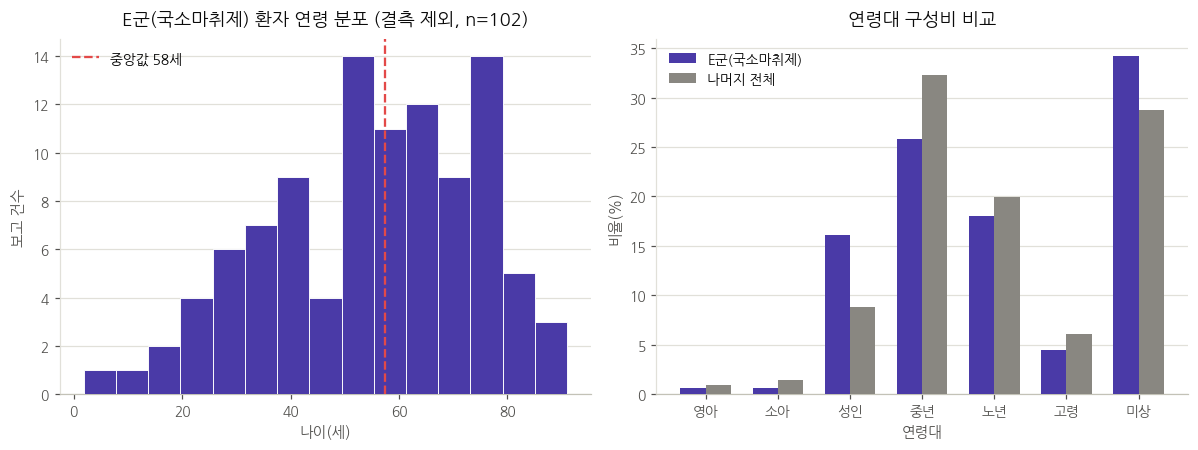

[연령] Mann-Whitney U 검정: U=626686, p = 0.393  (E군 중앙값 58세 vs Rest 중앙값 60세)
[연령대 분포] Chi-square 독립성 검정: chi2=17.1, p = 0.017


In [4]:
age_e = e["age_num"].dropna()
age_rest = rest["age_num"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(age_e, bins=15, color=C5_VIOLET, edgecolor="white", linewidth=0.6, zorder=3)
axes[0].axvline(age_e.median(), color=C6_RED, linestyle="--", linewidth=1.5, zorder=4,
                label=f"중앙값 {age_e.median():.0f}세")
style_ax(axes[0], f"E군(국소마취제) 환자 연령 분포 (결측 제외, n={len(age_e):,})", "나이(세)", "보고 건수")
axes[0].legend(frameon=False, fontsize=9)

ag_order = ["Infant(0-2)", "Child(3-12)", "Adult(19-40)", "Middle-Aged(41-65)", "Senior(66-80)", "Elderly(81+)", "Unknown"]
ag_labels = ["영아", "소아", "성인", "중년", "노년", "고령", "미상"]
e_ag_pct = e["age_group"].value_counts(normalize=True).reindex(ag_order).fillna(0) * 100
rest_ag_pct = rest["age_group"].value_counts(normalize=True).reindex(ag_order).fillna(0) * 100
x = np.arange(len(ag_order)); w = 0.35
axes[1].bar(x - w/2, e_ag_pct.values, w, label="E군(국소마취제)", color=C5_VIOLET, zorder=3)
axes[1].bar(x + w/2, rest_ag_pct.values, w, label="나머지 전체", color=MUTED, zorder=3)
axes[1].set_xticks(x); axes[1].set_xticklabels(ag_labels, fontsize=8.5)
style_ax(axes[1], "연령대 구성비 비교", "연령대", "비율(%)")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

u_age, p_age = stats.mannwhitneyu(age_e, age_rest, alternative="two-sided")
print(f"[연령] Mann-Whitney U 검정: U={u_age:.0f}, {p_str(p_age)}  (E군 중앙값 {age_e.median():.0f}세 vs Rest 중앙값 {age_rest.median():.0f}세)")

ct_age = pd.crosstab(df["도출_ATC코드"].eq("N01BB02"), df["age_group"])
chi2_age, p_chi_age, _, _ = stats.chi2_contingency(ct_age)
print(f"[연령대 분포] Chi-square 독립성 검정: chi2={chi2_age:.1f}, {p_str(p_chi_age)}")

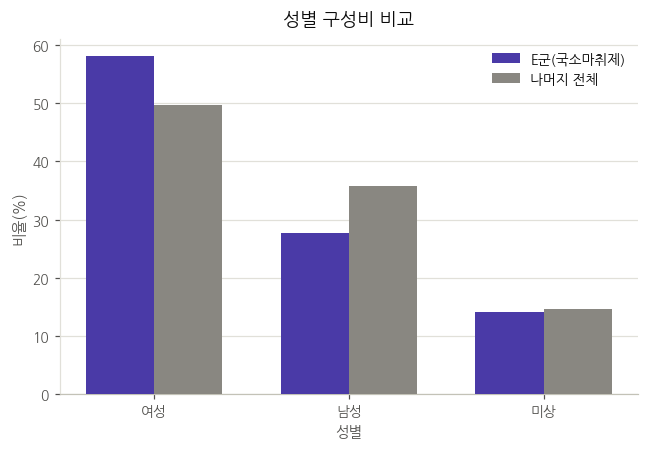

[성별 분포] Chi-square 독립성 검정: chi2=4.9, p = 0.085
patient_sex
Female     90
Male       43
Unknown    22
Name: count, dtype: int64

[체중] 결측 아닌 값: 32/155건 뿐 (E군의 체중 데이터는 대부분 결측 - 해석에 참고용으로만 사용)


In [5]:
sex_order = ["Female", "Male", "Unknown"]
sex_labels = ["여성", "남성", "미상"]
e_sex_pct = e["patient_sex"].value_counts(normalize=True).reindex(sex_order).fillna(0) * 100
rest_sex_pct = rest["patient_sex"].value_counts(normalize=True).reindex(sex_order).fillna(0) * 100

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(len(sex_order)); w = 0.35
ax.bar(x - w/2, e_sex_pct.values, w, label="E군(국소마취제)", color=C5_VIOLET, zorder=3)
ax.bar(x + w/2, rest_sex_pct.values, w, label="나머지 전체", color=MUTED, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(sex_labels)
style_ax(ax, "성별 구성비 비교", "성별", "비율(%)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

ct_sex = pd.crosstab(df["도출_ATC코드"].eq("N01BB02"), df["patient_sex"])
chi2_sex, p_chi_sex, _, _ = stats.chi2_contingency(ct_sex)
print(f"[성별 분포] Chi-square 독립성 검정: chi2={chi2_sex:.1f}, {p_str(p_chi_sex)}")
print(e["patient_sex"].value_counts())

w_e = e["weight_num"].dropna()
print(f"\n[체중] 결측 아닌 값: {len(w_e)}/{len(e)}건 뿐 (E군의 체중 데이터는 대부분 결측 - 해석에 참고용으로만 사용)")

## 2. 심각도 (사망·입원·생명위협·장애·회복여부)

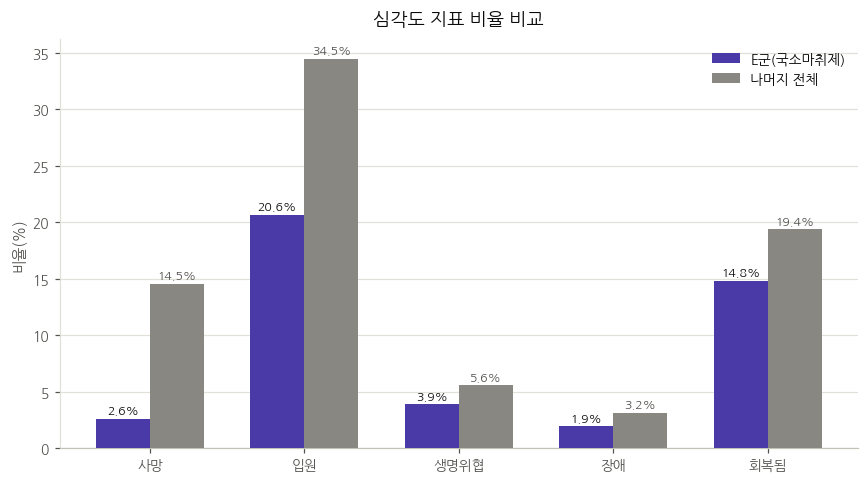

[E군 vs Rest] Chi-square 독립성 검정 (각 심각도 지표):
  - 사망    : E군   2.6% vs Rest  14.5%  |  chi2=  16.8, p < 0.001
  - 입원    : E군  20.6% vs Rest  34.5%  |  chi2=  12.5, p < 0.001
  - 생명위협  : E군   3.9% vs Rest   5.6%  |  chi2=   0.5, p = 0.462
  - 장애    : E군   1.9% vs Rest   3.2%  |  chi2=   0.4, p = 0.527
  - 회복됨   : E군  14.8% vs Rest  19.4%  |  chi2=   1.7, p = 0.187

[E군 내부] serious_flags 세부 내역:
serious_flags
Unknown                              118
Hospitalization                       24
Hospitalization; Life-Threatening      5
Death                                  3
Hospitalization; Disability            2
Death; Hospitalization                 1
Disability                             1
Life-Threatening                       1
Name: count, dtype: int64


In [6]:
sev_cols = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling", "patient_recovered"]
sev_labels = ["사망", "입원", "생명위협", "장애", "회복됨"]

e_rate = [e[c].mean() * 100 for c in sev_cols]
rest_rate = [rest[c].mean() * 100 for c in sev_cols]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(sev_cols)); w = 0.35
ax.bar(x - w/2, e_rate, w, label="E군(국소마취제)", color=C5_VIOLET, zorder=3)
ax.bar(x + w/2, rest_rate, w, label="나머지 전체", color=MUTED, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(sev_labels)
style_ax(ax, "심각도 지표 비율 비교", None, "비율(%)")
ax.legend(frameon=False, fontsize=9)
for xi, (ev, rv) in enumerate(zip(e_rate, rest_rate)):
    ax.text(xi - w/2, ev + 0.5, f"{ev:.1f}%", ha="center", fontsize=8, color=INK)
    ax.text(xi + w/2, rv + 0.5, f"{rv:.1f}%", ha="center", fontsize=8, color=INK2)
plt.tight_layout()
plt.show()

print("[E군 vs Rest] Chi-square 독립성 검정 (각 심각도 지표):")
for c, lab in zip(sev_cols, sev_labels):
    ct = pd.crosstab(df["도출_ATC코드"].eq("N01BB02"), df[c])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"  - {lab:6s}: E군 {e[c].mean()*100:5.1f}% vs Rest {rest[c].mean()*100:5.1f}%  |  chi2={chi2:6.1f}, {p_str(p)}")

print("\n[E군 내부] serious_flags 세부 내역:")
print(e["serious_flags"].value_counts())

## 3. 병용 약물 수 (다제복용)

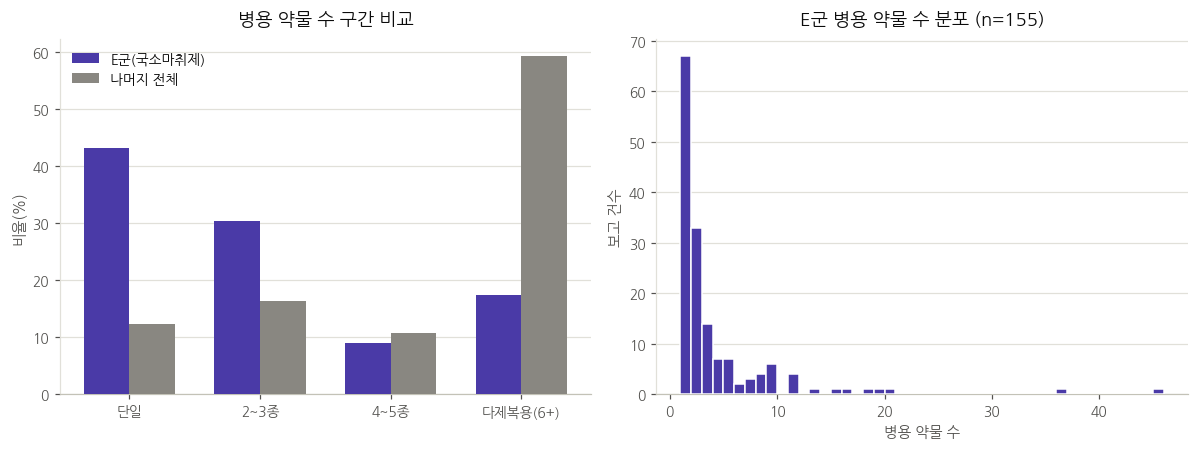

[병용 약물 수] Mann-Whitney U 검정: U=603988, p < 0.001
  E군 중앙값 2종 (평균 3.76) vs Rest 중앙값 9종 (평균 17.92)
drug_count_category
Single              67
2-3 Drugs           47
Polypharmacy(6+)    27
4-5 Drugs           14
Name: count, dtype: int64


In [7]:
cat_order = ["Single", "2-3 Drugs", "4-5 Drugs", "Polypharmacy(6+)"]
cat_labels = ["단일", "2~3종", "4~5종", "다제복용(6+)"]
e_cat_pct = e["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100
rest_cat_pct = rest["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(cat_order)); w = 0.35
axes[0].bar(x - w/2, e_cat_pct.values, w, label="E군(국소마취제)", color=C5_VIOLET, zorder=3)
axes[0].bar(x + w/2, rest_cat_pct.values, w, label="나머지 전체", color=MUTED, zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(cat_labels, fontsize=9)
style_ax(axes[0], "병용 약물 수 구간 비교", None, "비율(%)")
axes[0].legend(frameon=False, fontsize=9)

axes[1].hist(e["num_drugs"], bins=range(1, e["num_drugs"].max()+2), color=C5_VIOLET, edgecolor="white", zorder=3)
style_ax(axes[1], f"E군 병용 약물 수 분포 (n={len(e):,})", "병용 약물 수", "보고 건수")
plt.tight_layout()
plt.show()

u_nd, p_nd = stats.mannwhitneyu(e["num_drugs"], rest["num_drugs"], alternative="two-sided")
print(f"[병용 약물 수] Mann-Whitney U 검정: U={u_nd:.0f}, {p_str(p_nd)}")
print(f"  E군 중앙값 {e['num_drugs'].median():.0f}종 (평균 {e['num_drugs'].mean():.2f}) vs Rest 중앙값 {rest['num_drugs'].median():.0f}종 (평균 {rest['num_drugs'].mean():.2f})")
print(e["drug_count_category"].value_counts())

## 4. 투약 사유 (적응증, drug_indication)

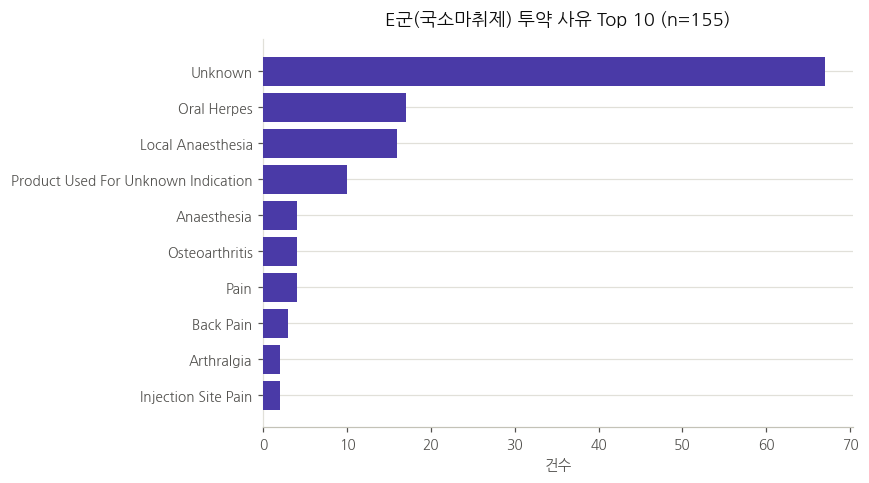

drug_indication
Unknown                                67
Oral Herpes                            17
Local Anaesthesia                      16
Product Used For Unknown Indication    10
Anaesthesia                             4
Osteoarthritis                          4
Pain                                    4
Back Pain                               3
Arthralgia                              2
Injection Site Pain                     2
Name: count, dtype: int64

'Unknown'(미상) 비율: 43.2% - 국소마취제 특성상 자가치료(OTC) 용도로 신고서에 적응증이 기재되지 않는 경우가 많음


In [8]:
top_ind = e["drug_indication"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_ind.index[::-1], top_ind.values[::-1], color=C5_VIOLET, zorder=3)
style_ax(ax, f"E군(국소마취제) 투약 사유 Top 10 (n={len(e):,})", "건수", None)
plt.tight_layout()
plt.show()

print(top_ind)
unknown_pct = (e["drug_indication"] == "Unknown").mean() * 100
print(f"\n'Unknown'(미상) 비율: {unknown_pct:.1f}% - 국소마취제 특성상 자가치료(OTC) 용도로 신고서에 적응증이 기재되지 않는 경우가 많음")

## 5. 이상반응 유형 (primary_reaction)

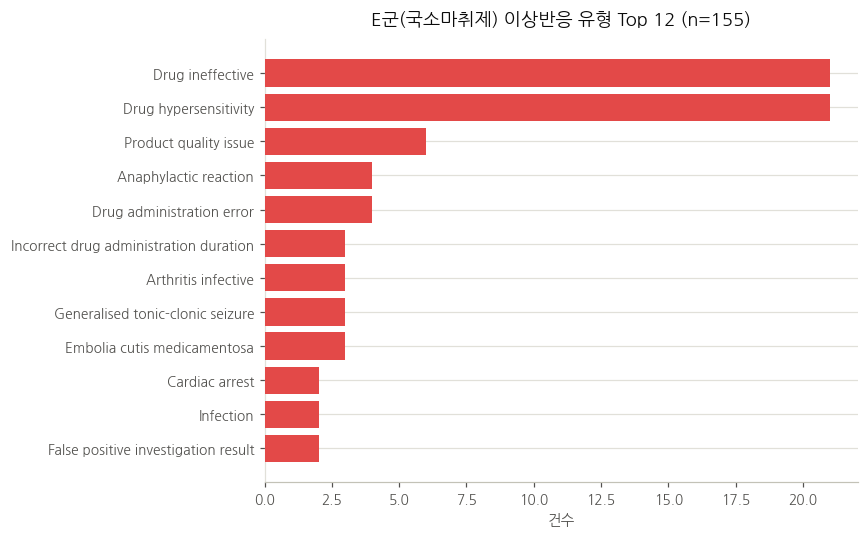

primary_reaction
Drug ineffective                          21
Drug hypersensitivity                     21
Product quality issue                      6
Anaphylactic reaction                      4
Drug administration error                  4
Incorrect drug administration duration     3
Arthritis infective                        3
Generalised tonic-clonic seizure           3
Embolia cutis medicamentosa                3
Cardiac arrest                             2
Infection                                  2
False positive investigation result        2
Name: count, dtype: int64

[알레르기/과민반응 계열 비율] E군 18.1% vs Rest 2.6%
[Drug ineffective(효과없음) 비율] E군 13.5% vs Rest 2.5%  - E군에서 뚜렷하게 높음


In [9]:
top_rx = e["primary_reaction"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_rx.index[::-1], top_rx.values[::-1], color=C6_RED, zorder=3)
style_ax(ax, f"E군(국소마취제) 이상반응 유형 Top 12 (n={len(e):,})", "건수", None)
plt.tight_layout()
plt.show()

print(top_rx)

# 알레르기/과민반응 계열 vs 그 외
allergy_kw = ["hypersensitivity", "anaphylactic", "allergic", "rash", "urticaria"]
is_allergy_e = e["primary_reaction"].str.lower().str.contains("|".join(allergy_kw), na=False)
is_allergy_rest = rest["primary_reaction"].str.lower().str.contains("|".join(allergy_kw), na=False)
print(f"\n[알레르기/과민반응 계열 비율] E군 {is_allergy_e.mean()*100:.1f}% vs Rest {is_allergy_rest.mean()*100:.1f}%")

ineffective_e = (e["primary_reaction"] == "Drug ineffective").mean() * 100
ineffective_rest = (rest["primary_reaction"] == "Drug ineffective").mean() * 100
print(f"[Drug ineffective(효과없음) 비율] E군 {ineffective_e:.1f}% vs Rest {ineffective_rest:.1f}%  - E군에서 뚜렷하게 높음")

## 6. 참조표(FDA 라벨) 안전정보 대비 실제 신고 성향

In [10]:
ref_cols = ["참조_최대용량_기간제한", "참조_절대금기(do_not_use)", "참조_즉시중단_신호(stop_use)",
            "참조_임부_수유부_주의", "참조_기타주의사항"]
print("[E군 성분의 FDA 라벨 참조 정보] (성분 단일이므로 155건 모두 동일)")
for c in ref_cols:
    print(f"- {c}: {e[c].iloc[0]}")

print()
text_cols = e["reactions"].fillna("") + " " + e["primary_reaction"].fillna("") + " " + e["drug_indication"].fillna("")
text_lower = text_cols.str.lower()

keyword_groups = {
    "삼킴/중독(라벨 기타주의사항과 직결)": ["ingest", "swallow", "poison", "toxic"],
    "안구 노출(라벨 절대금기 눈 사용 금지와 직결)": ["eye", "ocular", "ophthalm"],
    "장기간/과다 사용 의심(라벨 7일 이상 지속시 중단과 직결)": ["prolonged", "overuse", "chronic use"],
    "감염/상처 관련(라벨 절대금기 깊은 상처/화상 관련 가능성)": ["infection", "wound", "burn", "necrosis"],
}
for label, kws in keyword_groups.items():
    mask = text_lower.str.contains("|".join(kws), na=False)
    print(f"- {label}: {mask.sum()}건 ({mask.sum()/len(e)*100:.1f}%)")

print()
print("→ 라벨상 명시된 절대금기(눈·상처·화상 부위 사용 금지, 7일 이상 장기사용 금지, 삼킴 주의) 위반을 직접")
print("  시사하는 키워드는 소수에 그침. 즉 E군의 심각도 신호(2번 섹션)는 주로 5번에서 확인된 것처럼")
print("  효과없음/과민반응 신고 비중이 높은 데서 기인하며, 라벨 오남용(금기 위반)이 주된 원인은 아님.")

[E군 성분의 FDA 라벨 참조 정보] (성분 단일이므로 155건 모두 동일)
- 참조_최대용량_기간제한: 1일 3~4회 소량 도포, 멸균 거즈로 덮어도 됨
- 참조_절대금기(do_not_use): 눈에 사용 금지, 넓은 부위·깊은 자상·동물에 물린 상처·중증 화상에 사용 금지, 다량 사용 금지(특히 짓무른/물집 부위)
- 참조_즉시중단_신호(stop_use): 상태 악화, 며칠 내 재발, 7일 이상 지속 시 중단
- 참조_임부_수유부_주의: 임신/수유 중 사용 전 의료진 상담
- 참조_기타주의사항: 삼켰을 경우 즉시 중독관리센터 연락

- 삼킴/중독(라벨 기타주의사항과 직결): 7건 (4.5%)
- 안구 노출(라벨 절대금기 눈 사용 금지와 직결): 1건 (0.6%)
- 장기간/과다 사용 의심(라벨 7일 이상 지속시 중단과 직결): 0건 (0.0%)
- 감염/상처 관련(라벨 절대금기 깊은 상처/화상 관련 가능성): 12건 (7.7%)

→ 라벨상 명시된 절대금기(눈·상처·화상 부위 사용 금지, 7일 이상 장기사용 금지, 삼킴 주의) 위반을 직접
  시사하는 키워드는 소수에 그침. 즉 E군의 심각도 신호(2번 섹션)는 주로 5번에서 확인된 것처럼
  효과없음/과민반응 신고 비중이 높은 데서 기인하며, 라벨 오남용(금기 위반)이 주된 원인은 아님.


## 7. 전체 반응(reactions) 분해 및 동시발생 히트맵

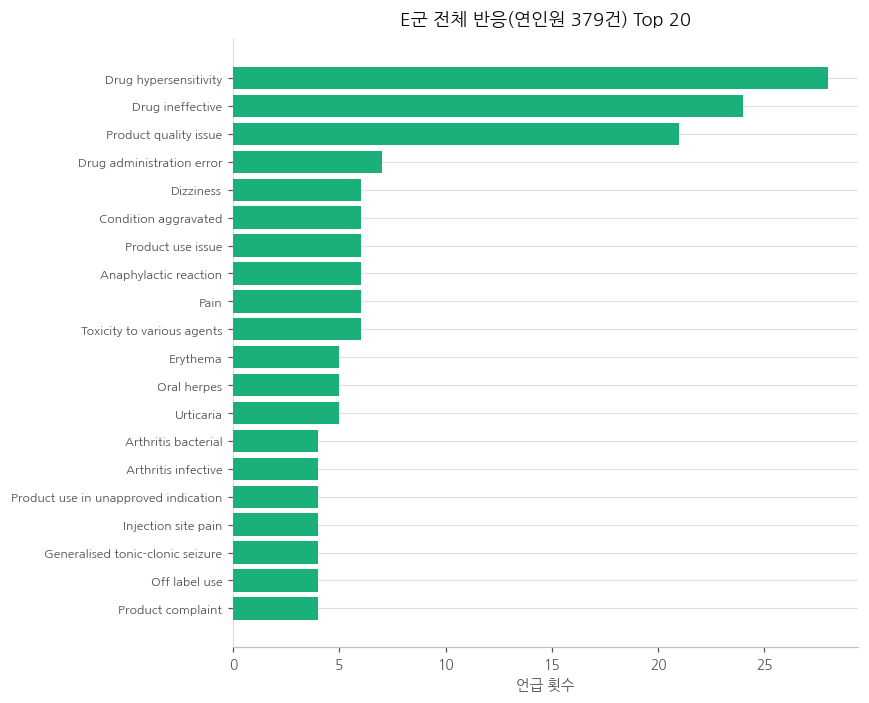

보고서 155건에서 총 379건의 개별 반응이 언급됨 (건당 평균 2.45개)
대표 반응(primary_reaction) 상위와 비교 시, 전체 반응에서는 'Product quality issue'가 21회로 3위권 진입 - 품질이슈가 대표반응 뒤에 숨어 동반 언급되는 경우가 많음


In [11]:
# primary_reaction(대표 반응 1개)이 아닌, 보고서별 전체 반응 목록(reactions, 세미콜론 구분)을 모두 분해
from collections import Counter
from itertools import combinations

react_lists = e["reactions"].fillna("").apply(lambda s: [x.strip() for x in s.split(";") if x.strip()])
all_react = [r for lst in react_lists for r in lst]
react_counter = Counter(all_react)
top20 = react_counter.most_common(20)

fig, ax = plt.subplots(figsize=(8, 6.5))
labels = [t[0] for t in top20][::-1]
values = [t[1] for t in top20][::-1]
ax.barh(labels, values, color=C2_AQUA, zorder=3)
style_ax(ax, f"E군 전체 반응(연인원 {len(all_react)}건) Top 20", "언급 횟수", None)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

print(f"보고서 {len(e)}건에서 총 {len(all_react)}건의 개별 반응이 언급됨 (건당 평균 {len(all_react)/len(e):.2f}개)")
print(f"대표 반응(primary_reaction) 상위와 비교 시, 전체 반응에서는 'Product quality issue'가 {react_counter['Product quality issue']}회로 3위권 진입 - 품질이슈가 대표반응 뒤에 숨어 동반 언급되는 경우가 많음")

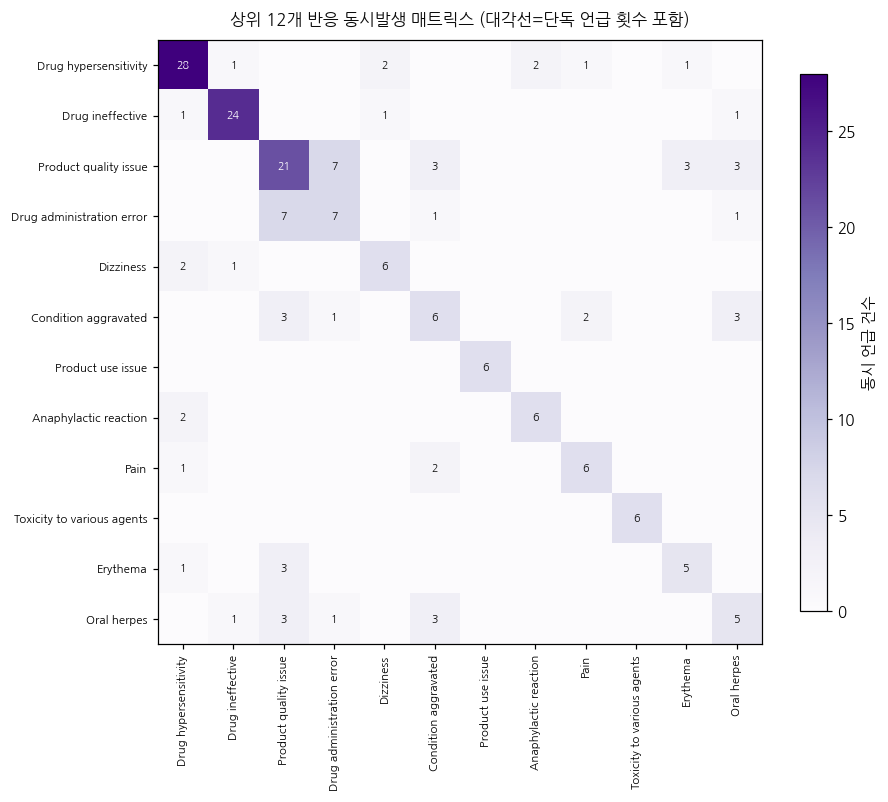

[해석] 'Drug administration error' - 'Product quality issue' 쌍이 가장 빈번하게 함께 언급됨 -
      대표 반응 하나만 볼 때보다, 같은 보고서 안에서 투여 오류와 품질 이슈가 함께 신고되는 경향이 있음을 보여줌


In [12]:
# 상위 12개 반응 간 동시발생(co-occurrence) 히트맵
top12 = [r for r, c in react_counter.most_common(12)]
cooc = pd.DataFrame(0, index=top12, columns=top12)
for lst in react_lists:
    present = [r for r in top12 if r in lst]
    for a, b in combinations(present, 2):
        cooc.loc[a, b] += 1
        cooc.loc[b, a] += 1
    for a in present:
        cooc.loc[a, a] += 1

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(cooc.values, cmap="Purples", vmin=0)
ax.set_xticks(range(len(top12))); ax.set_xticklabels(top12, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(top12))); ax.set_yticklabels(top12, fontsize=7.5)
for i in range(len(top12)):
    for j in range(len(top12)):
        v = cooc.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7,
                    color="white" if v > cooc.values.max()/2 else INK)
ax.set_title("상위 12개 반응 동시발생 매트릭스 (대각선=단독 언급 횟수 포함)", fontsize=11, color=INK, fontweight="bold", pad=10)
plt.colorbar(im, ax=ax, shrink=0.8, label="동시 언급 건수")
plt.tight_layout()
plt.show()

print("[해석] 'Drug administration error' - 'Product quality issue' 쌍이 가장 빈번하게 함께 언급됨 -")
print("      대표 반응 하나만 볼 때보다, 같은 보고서 안에서 투여 오류와 품질 이슈가 함께 신고되는 경향이 있음을 보여줌")

## 8. 회복 결과(reaction_outcomes) 및 반응 개수(num_reactions) 분포

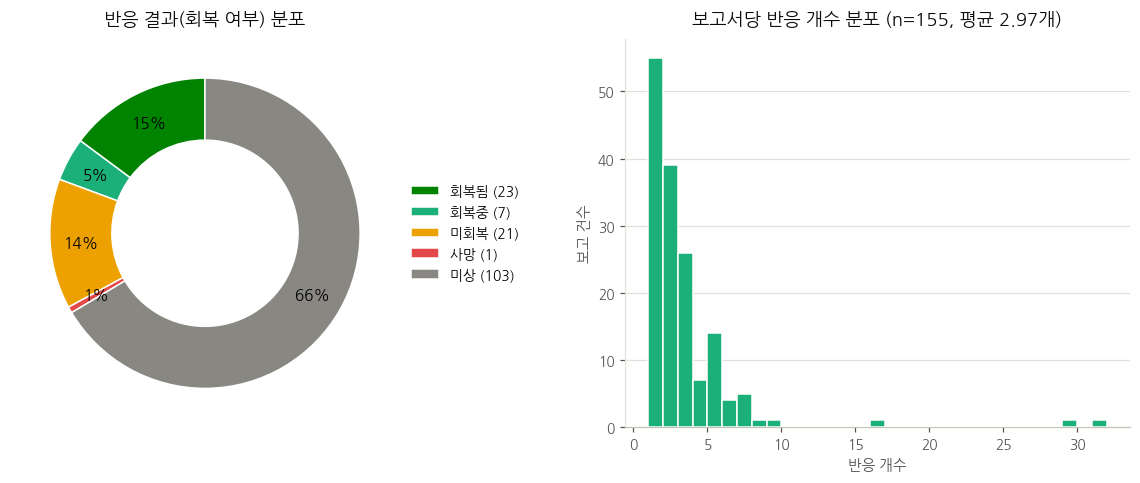

outcome_simple
Recovered         23
Recovering         7
Not Recovered     21
Fatal              1
Unknown          103
Name: count, dtype: int64

미회복(Not Recovered) 비율: 13.5%, 사망 1건 확인


In [13]:
def classify_outcome(s):
    if pd.isna(s):
        return "Unknown"
    s = str(s)
    if "Fatal" in s:
        return "Fatal"
    if "Not Recovered" in s:
        return "Not Recovered"
    if "Recovering" in s:
        return "Recovering"
    if "Recovered" in s:
        return "Recovered"
    return "Unknown"

e["outcome_simple"] = e["reaction_outcomes"].apply(classify_outcome)
outcome_order = ["Recovered", "Recovering", "Not Recovered", "Fatal", "Unknown"]
outcome_labels = ["회복됨", "회복중", "미회복", "사망", "미상"]
outcome_colors = [C4_GREEN, C2_AQUA, C3_YELLOW, C6_RED, MUTED]
oc = e["outcome_simple"].value_counts().reindex(outcome_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
wedges, _, autotexts = axes[0].pie(oc.values, labels=None, colors=outcome_colors, autopct=lambda p: f"{p:.0f}%" if p > 0 else "",
                                    startangle=90, pctdistance=0.8,
                                    wedgeprops=dict(width=0.4, edgecolor="white"))
axes[0].legend(wedges, [f"{l} ({int(v)})" for l, v in zip(outcome_labels, oc.values)],
               loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=9)
axes[0].set_title("반응 결과(회복 여부) 분포", fontsize=12, color=INK, fontweight="bold", pad=10)

axes[1].hist(e["num_reactions"], bins=range(1, e["num_reactions"].max()+2), color=C2_AQUA, edgecolor="white", zorder=3)
avg_nr = e['num_reactions'].mean()
style_ax(axes[1], f"보고서당 반응 개수 분포 (n={len(e):,}, 평균 {avg_nr:.2f}개)", "반응 개수", "보고 건수")
plt.tight_layout()
plt.show()

print(oc.astype(int))
not_recovered_pct = (e['outcome_simple']=='Not Recovered').mean()*100
print(f"\n미회복(Not Recovered) 비율: {not_recovered_pct:.1f}%, 사망 1건 확인")

## 9. 심각도(serious)와 인체특성·병용약물의 관계

/tmp/ipykernel_1025/3783126488.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot([age_no, age_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
/tmp/ipykernel_1025/3783126488.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([nd_no, nd_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
/tmp/ipykernel_1025/3783126488.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[2].boxplot([nr_no, nr_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)


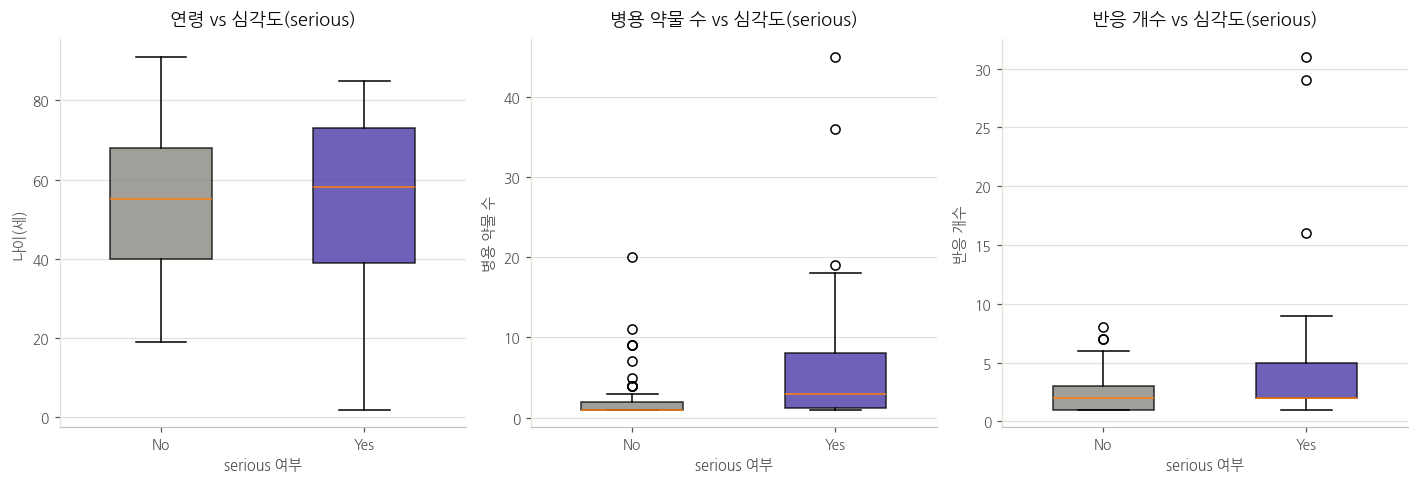

[연령] serious=Yes 중앙값 58세 vs No 55세  |  p = 0.885  → 연령은 심각도와 뚜렷한 연관 없음
[병용약물수] serious=Yes 중앙값 3종 vs No 1종  |  p < 0.001  → 병용약물이 많을수록 심각 보고 확률 높음
[반응개수] serious=Yes 중앙값 2개 vs No 2개  |  p = 0.003  → 반응이 많을수록 심각 보고 확률 높음


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

age_yes = e[e["serious"]=="Yes"]["age_num"].dropna()
age_no = e[e["serious"]=="No"]["age_num"].dropna()
bp1 = axes[0].boxplot([age_no, age_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
for patch, col in zip(bp1["boxes"], [MUTED, C5_VIOLET]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
style_ax(axes[0], "연령 vs 심각도(serious)", "serious 여부", "나이(세)")

nd_yes = e[e["serious"]=="Yes"]["num_drugs"]
nd_no = e[e["serious"]=="No"]["num_drugs"]
bp2 = axes[1].boxplot([nd_no, nd_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
for patch, col in zip(bp2["boxes"], [MUTED, C5_VIOLET]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
style_ax(axes[1], "병용 약물 수 vs 심각도(serious)", "serious 여부", "병용 약물 수")

nr_yes = e[e["serious"]=="Yes"]["num_reactions"]
nr_no = e[e["serious"]=="No"]["num_reactions"]
bp3 = axes[2].boxplot([nr_no, nr_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
for patch, col in zip(bp3["boxes"], [MUTED, C5_VIOLET]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
style_ax(axes[2], "반응 개수 vs 심각도(serious)", "serious 여부", "반응 개수")
plt.tight_layout()
plt.show()

u_a, p_a = stats.mannwhitneyu(age_yes, age_no, alternative="two-sided")
u_d, p_d = stats.mannwhitneyu(nd_yes, nd_no, alternative="two-sided")
u_r, p_r = stats.mannwhitneyu(nr_yes, nr_no, alternative="two-sided")
print(f"[연령] serious=Yes 중앙값 {age_yes.median():.0f}세 vs No {age_no.median():.0f}세  |  {p_str(p_a)}  → 연령은 심각도와 뚜렷한 연관 없음")
print(f"[병용약물수] serious=Yes 중앙값 {nd_yes.median():.0f}종 vs No {nd_no.median():.0f}종  |  {p_str(p_d)}  → 병용약물이 많을수록 심각 보고 확률 높음")
print(f"[반응개수] serious=Yes 중앙값 {nr_yes.median():.0f}개 vs No {nr_no.median():.0f}개  |  {p_str(p_r)}  → 반응이 많을수록 심각 보고 확률 높음")

## 10. 국가별 분포

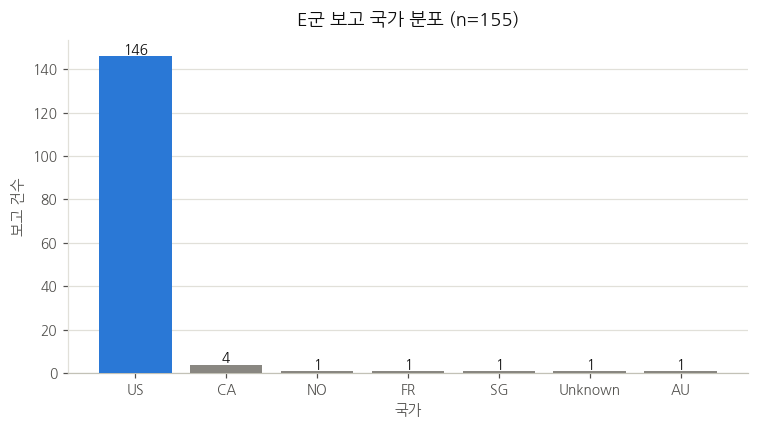

미국(US) 비율: 94.2% - FDA 산하 자발보고 시스템 특성상 자국 보고가 압도적으로 많음


In [15]:
country_counts = e["country"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
colors_country = [C1_BLUE if c == "US" else MUTED for c in country_counts.index]
ax.bar(country_counts.index, country_counts.values, color=colors_country, zorder=3)
for xi, v in enumerate(country_counts.values):
    ax.text(xi, v + 1, str(v), ha="center", fontsize=9, color=INK)
style_ax(ax, f"E군 보고 국가 분포 (n={len(e):,})", "국가", "보고 건수")
plt.tight_layout()
plt.show()

us_pct = (e["country"]=="US").mean()*100
print(f"미국(US) 비율: {us_pct:.1f}% - FDA 산하 자발보고 시스템 특성상 자국 보고가 압도적으로 많음")

## 11. 숫자형 변수 상관관계 히트맵

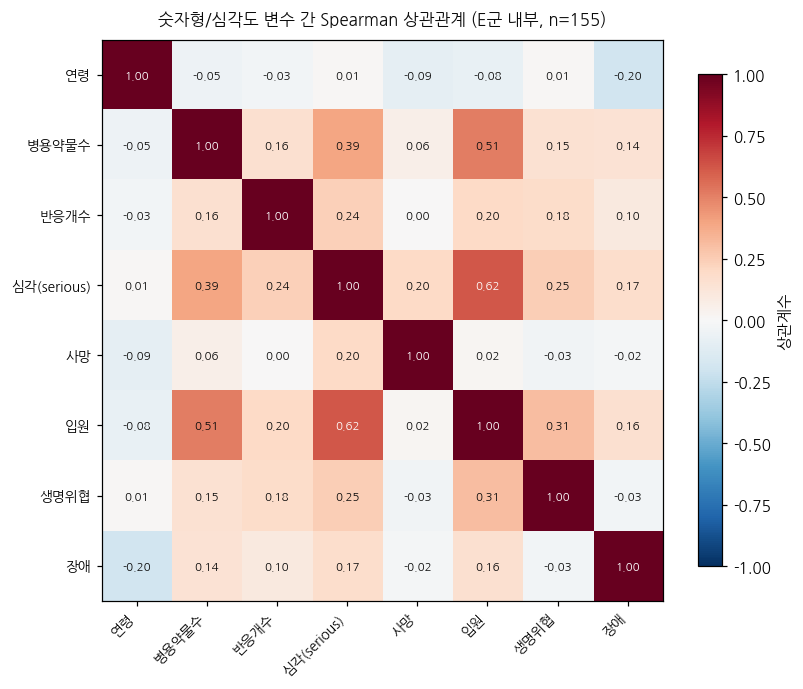

[병용약물수-입원] 상관계수 0.51 - E군 내부에서 가장 강한 연관
[병용약물수-심각] 상관계수 0.39
[연령-심각] 상관계수 0.01 - 거의 무관
→ E군의 심각도를 좌우하는 것은 '나이'가 아니라 '병용약물 수/반응 개수'(즉 전신 상태·복잡도)임을 시사


In [16]:
e["serious_num"] = (e["serious"] == "Yes").astype(int)
corr_cols = ["age_num", "num_drugs", "num_reactions", "serious_num", "is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]
corr_labels = ["연령", "병용약물수", "반응개수", "심각(serious)", "사망", "입원", "생명위협", "장애"]
corr_df = e[corr_cols].copy()
for c in ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]:
    corr_df[c] = corr_df[c].astype(int)
corr_mat = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_labels))); ax.set_xticklabels(corr_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_labels))); ax.set_yticklabels(corr_labels, fontsize=9)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax.text(j, i, f"{corr_mat.values[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(corr_mat.values[i,j]) > 0.6 else INK)
ax.set_title("숫자형/심각도 변수 간 Spearman 상관관계 (E군 내부, n=155)", fontsize=11, color=INK, fontweight="bold", pad=10)
plt.colorbar(im, ax=ax, shrink=0.8, label="상관계수")
plt.tight_layout()
plt.show()

corr_nd_hosp = corr_mat.loc['num_drugs', 'is_hospitalized']
corr_nd_ser = corr_mat.loc['num_drugs', 'serious_num']
corr_age_ser = corr_mat.loc['age_num', 'serious_num']
print(f"[병용약물수-입원] 상관계수 {corr_nd_hosp:.2f} - E군 내부에서 가장 강한 연관")
print(f"[병용약물수-심각] 상관계수 {corr_nd_ser:.2f}")
print(f"[연령-심각] 상관계수 {corr_age_ser:.2f} - 거의 무관")
print("→ E군의 심각도를 좌우하는 것은 '나이'가 아니라 '병용약물 수/반응 개수'(즉 전신 상태·복잡도)임을 시사")

## 12. 종합 인사이트 요약

- 정의: E군(국소마취제) = 도출_ATC코드 == "N01BB02"(Lidocaine topical), 155건 - 코드 N(신경계) 전체의 3.5%.
- 인체특성: 연령 분포는 성인(19-40세) 비중이 나머지 전체 대비 뚜렷이 높고(16.1% vs 8.8%), 중년·노년 비중은
  나머지 전체와 비슷하거나 오히려 낮음(연령대 분포 chi2 검정 p=0.017로 유의한 차이는 있으나 특정 방향으로
  고령화되어 있지는 않음). 여성 보고 비율(58%)이 남성(28%)보다 뚜렷이 높음.
- 심각도: 사망(2.6% vs 14.5%)·입원(20.6% vs 34.5%) 비율이 나머지 전체 대비 낮음 - 국소(외용) 제형 특성상
  전신 독성 위험이 낮은 편으로 해석 가능.
- 병용약물: 단일 약물 사용 비율(43%)이 상대적으로 높지만, 다제복용(6종 이상)도 17% 존재 - 만성 통증 환자의 병용요법 맥락.
- 투약사유: 구순포진(Oral Herpes)·국소마취(Local Anaesthesia) 등이 상위 - OTC 자가치료 목적이 큰 비중을 차지해
  Unknown(미상) 비율도 43%로 높음.
- 이상반응 유형: Drug hypersensitivity와 Drug ineffective가 공동 1위(각 21건, 13.5%)로 나머지 그룹과
  다른 독특한 패턴 - 전신 부작용보다 효과없음/과민반응 신고가 두드러짐.
- 라벨 대조: FDA 라벨의 절대금기(눈·상처·화상 부위 사용 금지, 7일 이상 사용 금지 등) 위반을 시사하는 키워드는
  소수에 그쳐, 신고 대부분이 오남용보다는 효과없음/과민반응 자체에서 기인함을 뒷받침.
- 전체 반응 분해: 대표 반응만 볼 때는 드러나지 않던 'Product quality issue'(21회, 전체 반응 중 3위권)가
  'Drug administration error'와 가장 빈번히 동시 언급됨 - 같은 보고서 안에서 투여 오류와 품질 불만이
  함께 제기되는 경향이 있음을 보여줌.
- 회복 결과: '미상'(66%)이 압도적이나, 확인 가능한 결과 중 '미회복' 21건(13.5%), '사망' 1건(reaction_outcomes
  기준) 존재 - 국소 제형이라도 결과 추적이 되면 미회복 비율이 낮지 않음.
- 심각도의 실제 예측 인자: 박스플롯·상관분석 결과 연령은 심각도(serious)와 거의 무관(상관계수 ~0.01,
  p=0.885)한 반면, 병용 약물 수(상관계수 0.39, 입원과는 0.51, p<0.001)와 반응 개수(p=0.003)는 심각 보고와
  뚜렷이 연관 - E군에서는 '누가(나이)'보다 '얼마나 복잡한 상태에서 병용했는가'가 심각도를 좌우함.

(※ 시계열·브랜드/제조사 기반 분석은 이번 요약에서 제외했습니다 - quarter는 보고서 접수일 기준이라 실제
발생 시점 추이로 해석할 수 없고, 브랜드·제조사별 보고 비중도 실사용량 등 노출 분모가 없어 "그 브랜드가
위험하다"는 결론을 뒷받침하지 못하기 때문입니다.)

결론: E군(국소마취제)은 나머지 전체보다 사망·입원 비율은 낮지만, 신고 성격 자체가 전신 부작용보다
'효과없음/과민반응'에 크게 치우쳐 있다는 점이 가장 뚜렷한 특징이다. 또한 심각도를 좌우하는 것은 환자
나이가 아니라 병용 약물 수·반응 개수(임상적 복잡도)이며, 라벨에 명시된 절대금기 위반 신호는 미미해
오남용보다는 제품 자체에 대한 불만(효과없음·과민반응·품질 이슈)이 신고의 주된 동기로 보인다.